# Episode inspector

Single-episode deep-look over one `episode.hdf5`. Complements the dataset-wide manifest with a per-episode view: structure, attributes, the state/engagement timeline, gaze validity, gripper and end-effector behaviour, scene config, and a few sample frames.

Set `EPISODE_PATH` below and run all cells.

In [1]:
import h5py
import numpy as np
import matplotlib.pyplot as plt

EPISODE_PATH = r"C:/Users/ceti/Documents/05_data/teleop-sorting/avatar/000/episode.hdf5"

STATE_NAMES = {0: "OFFLINE", 1: "IDLE", 2: "HOMING", 3: "AWAITING", 4: "ENGAGED",
               5: "PAUSED", 6: "FAULT", 7: "STOP", 8: "RECOVERING", 255: "UNDEFINED"}
ENGAGED = 4

f = h5py.File(EPISODE_PATH, "r")
print(EPISODE_PATH)

C:/Users/ceti/Documents/05_data/teleop-sorting/avatar/000/episode.hdf5


## Attributes

In [2]:
for k in f.attrs:
    v = f.attrs[k]
    if isinstance(v, bytes):
        v = v.decode("utf-8", errors="replace")
    print(f"  {k:<20s} {v}")

  color_bin_mapping    {"blue": "bin_1", "red": "bin_2"}
  episode_id           000
  image_scale          0.25
  mode                 1
  rate_hz              30.0
  schema_version       2
  seed                 176863867
  success              success


## Structure

In [3]:
def show(name, obj):
    indent = "  " * name.count("/")
    short = name.split("/")[-1]
    if isinstance(obj, h5py.Dataset):
        print(f"{indent}{short:32s} {str(obj.shape):18s} {obj.dtype}")
    else:
        print(f"{indent}{short}/")

f.visititems(show)

actions/
  arm_left/
    O_T_EE_cmd                       (2529, 16)         float64
    gripper_cmd                      (2529,)            float64
    q_cmd                            (2529, 7)          float64
  arm_right/
    O_T_EE_cmd                       (2529, 16)         float64
    gripper_cmd                      (2529,)            float64
    q_cmd                            (2529, 7)          float64
observations/
  arm_left/
    F_ext                            (2529, 6)          float64
    O_T_EE                           (2529, 16)         float64
    dq                               (2529, 7)          float64
    gripper_width                    (2529,)            float64
    q                                (2529, 7)          float64
    state                            (2529,)            int64
    tau_J                            (2529, 7)          float64
    tau_ext                          (2529, 7)          float64
  arm_right/
    F_ext                        

## Timeline: grid, state / engagement, gaze validity

Confirms the 30 Hz grid is clean and shows which portion of the episode is actually ENGAGED (the trainable region). Gaze validity is reported overall and over engaged frames only.

In [4]:
obs = f["observations"]
ts = obs["timestamp_ns"][:]
t = (ts - ts[0]) / 1e9
dt_ms = np.diff(ts) / 1e6
print(f"frames={len(ts)}  dur={t[-1]:.1f}s  rate~{(len(ts)-1)/t[-1]:.1f}Hz")
print(f"frame gap: mean={dt_ms.mean():.1f}ms  min={dt_ms.min():.1f}  max={dt_ms.max():.1f}")

states = {arm: obs[arm]["state"][:].astype(int) for arm in ("arm_left", "arm_right")
          if arm in obs and "state" in obs[arm]}
if states:
    eng = np.ones(len(ts), dtype=bool)
    for s in states.values():
        eng &= (s == ENGAGED)
    print(f"engaged frames: {eng.sum()} / {len(eng)}  ({eng.mean()*100:.1f}%)")
else:
    eng = None
    print("no per-arm state in hdf5 (re-run converter to add it)")

intent = obs.get("intent")
if intent is not None and "gaze_valid" in intent:
    gv = intent["gaze_valid"][:] > 0.5
    print(f"gaze valid (all):     {gv.mean()*100:.1f}%")
    if eng is not None and eng.sum():
        print(f"gaze valid (engaged): {gv[eng].mean()*100:.1f}%")

frames=2529  dur=84.3s  rate~30.0Hz
frame gap: mean=33.3ms  min=33.3  max=33.3
engaged frames: 1543 / 2529  (61.0%)
gaze valid (all):     99.3%
gaze valid (engaged): 98.8%


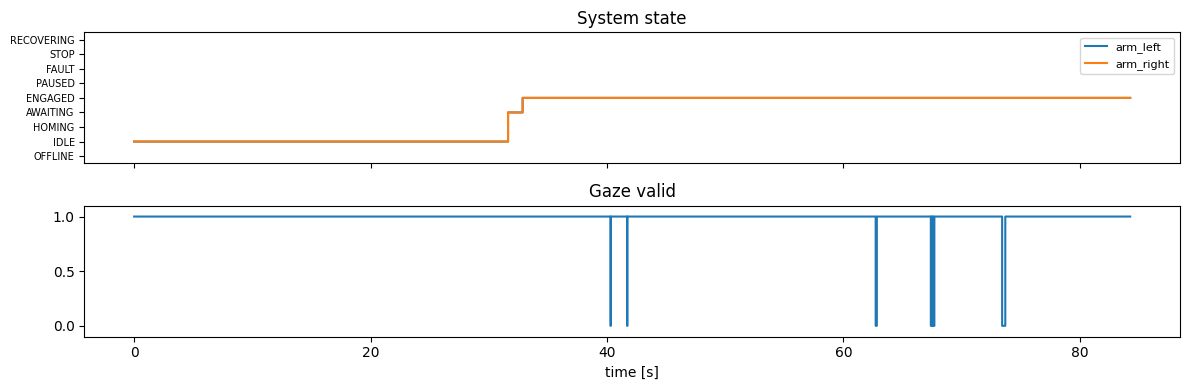

In [5]:
fig, ax = plt.subplots(2, 1, figsize=(12, 4), sharex=True)
for arm, s in states.items():
    ax[0].plot(t, s, label=arm, drawstyle="steps-post")
ax[0].set_yticks(sorted(STATE_NAMES)); ax[0].set_yticklabels([STATE_NAMES[k] for k in sorted(STATE_NAMES)], fontsize=7)
ax[0].set_ylim(-0.5, 8.5); ax[0].legend(fontsize=8); ax[0].set_title("System state")
if intent is not None and "gaze_valid" in intent:
    ax[1].plot(t, intent["gaze_valid"][:], drawstyle="steps-post")
ax[1].set_title("Gaze valid"); ax[1].set_xlabel("time [s]"); ax[1].set_ylim(-0.1, 1.1)
plt.tight_layout(); plt.show()

## Gripper and end-effector

Grasp events show as dips in gripper width; EE traces show the reach/transport motion. The engaged region is shaded.

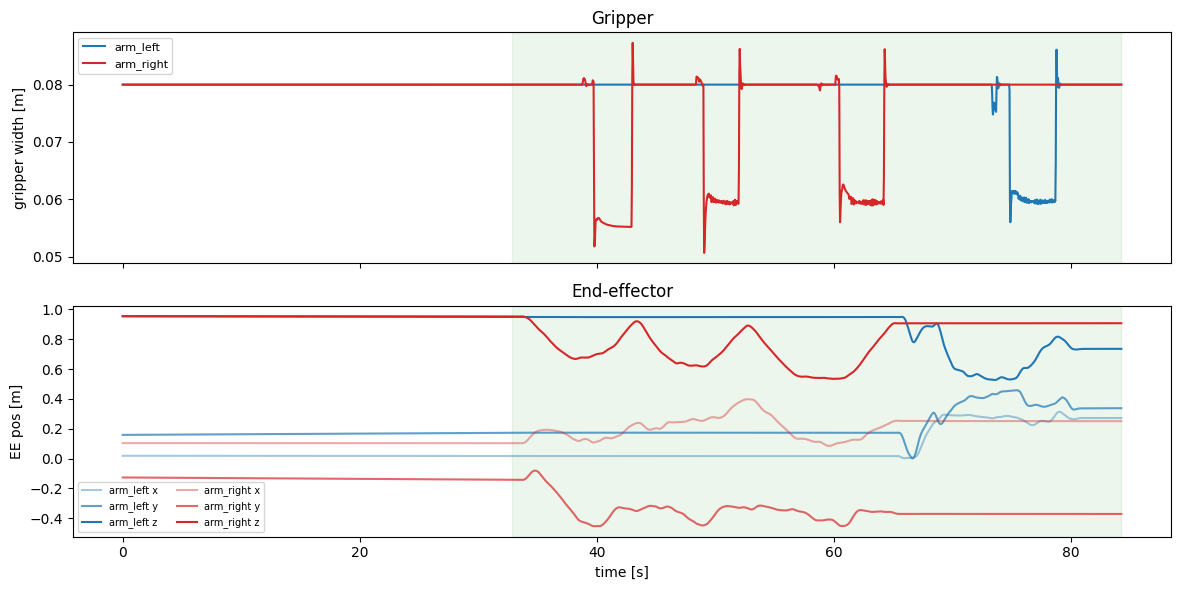

In [6]:
def shade_engaged(ax):
    if eng is None:
        return
    edges = np.diff(eng.astype(int))
    starts = list(np.where(edges == 1)[0] + 1)
    ends = list(np.where(edges == -1)[0] + 1)
    if eng[0]:
        starts = [0] + starts
    if eng[-1]:
        ends = ends + [len(eng) - 1]
    for a, b in zip(starts, ends):
        ax.axvspan(t[a], t[b], color="green", alpha=0.07)

fig, ax = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
for arm, c in (("arm_left", "tab:blue"), ("arm_right", "tab:red")):
    if arm in obs and "gripper_width" in obs[arm]:
        ax[0].plot(t, obs[arm]["gripper_width"][:], color=c, label=arm)
ax[0].set_ylabel("gripper width [m]"); ax[0].legend(fontsize=8); ax[0].set_title("Gripper"); shade_engaged(ax[0])

for arm, c in (("arm_left", "tab:blue"), ("arm_right", "tab:red")):
    if arm in obs and "O_T_EE" in obs[arm]:
        T = obs[arm]["O_T_EE"][:]
        pos = T[:, 12:15] if T.shape[1] == 16 else T[:, :3]
        for j, axis in enumerate("xyz"):
            ax[1].plot(t, pos[:, j], color=c, alpha=0.4 + 0.3 * j, label=f"{arm} {axis}")
ax[1].set_ylabel("EE pos [m]"); ax[1].set_xlabel("time [s]"); ax[1].legend(fontsize=7, ncol=2); ax[1].set_title("End-effector"); shade_engaged(ax[1])
plt.tight_layout(); plt.show()

## Scene config

In [7]:
scene = f.get("scene")
if scene is not None:
    for i in range(8):
        k = f"obj{i}_pose"
        if k in scene:
            p = scene[k][0]
            color = scene[f"obj{i}_color"][()] if f"obj{i}_color" in scene else b"?"
            color = color.decode() if isinstance(color, bytes) else color
            print(f"  obj{i} [{color:>4s}] pos=({p[0]:.3f}, {p[1]:.3f}, {p[2]:.3f})")
    for i in range(8):
        k = f"bin{i}_pose"
        if k in scene:
            p = scene[k][0]
            print(f"bin{i} pos=({p[0]:.3f}, {p[1]:.3f}, {p[2]:.3f})")

  obj0 [ red] pos=(0.517, -0.300, 0.724)
  obj1 [ red] pos=(0.701, -0.272, 0.723)
  obj2 [blue] pos=(0.460, 0.109, 0.725)
  obj3 [blue] pos=(0.589, -0.132, 0.725)
bin0 pos=(0.860, 0.100, 0.702)
bin1 pos=(0.860, -0.100, 0.702)


## Sample frames

A few frames from each camera at the stored (downscaled) resolution — the resolution the policy actually sees. Check the colour cue is legible here, not just in the full-res sim view.

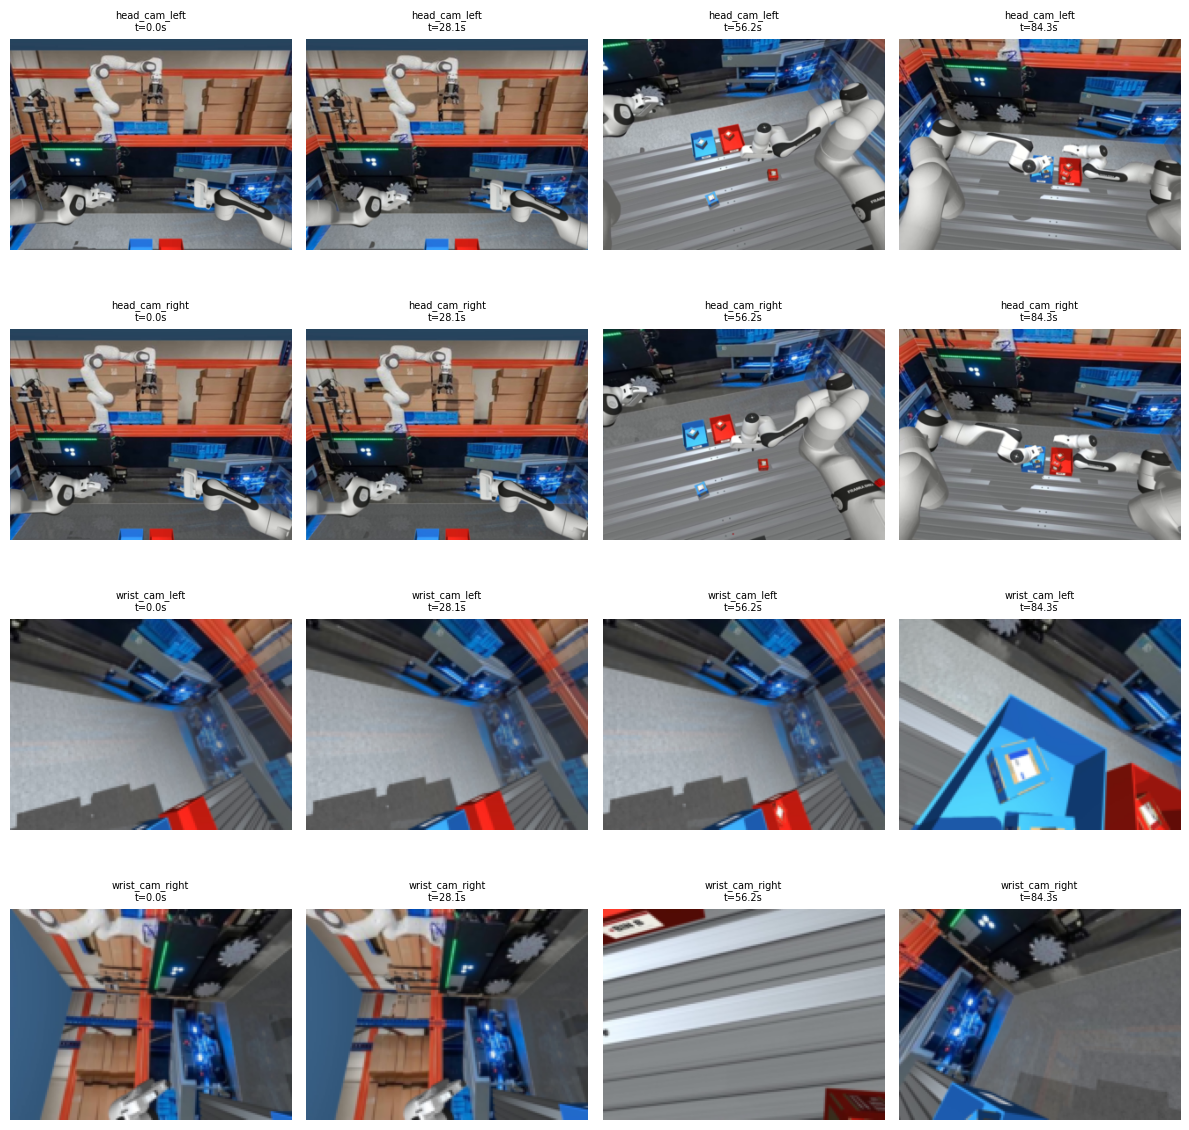

In [8]:
imgs = obs.get("images")
if imgs is not None:
    cams = list(imgs.keys())
    n = 4
    fig, axes = plt.subplots(len(cams), n, figsize=(3 * n, 3 * len(cams)))
    axes = np.atleast_2d(axes)
    idxs = np.linspace(0, len(ts) - 1, n).astype(int)
    for r, cam in enumerate(cams):
        for c, fi in enumerate(idxs):
            axes[r, c].imshow(imgs[cam][fi])
            axes[r, c].axis("off")
            axes[r, c].set_title(f"{cam}\nt={t[fi]:.1f}s", fontsize=7)
    plt.tight_layout(); plt.show()

In [9]:
f.close()